# SLM Labs v3 — Thai Sign Language → open-vocabulary extraction → LLM → Thai → เสียงพูด

**env: `conda activate hugging` (torch GPU)** · package [`slm_labs/`](slm_labs) · driver [`run_v3.py`](run_v3.py) · บันทึกผล [`prompt/result/fixed_v2.md`](prompt/result/fixed_v2.md)

```
.mp4 (fps อะไรก็ได้ / ถ่ายที่ไหนก็ได้)
   │  extractor.py  MediaPipe Holistic → landmark  ─┐
   │                                                ├─► **resample ที่ cfg.TARGET_FPS เดียวกันทั้งคู่**
   │  dataset TSL-51 landmark CSV (~24-30 fps)     ─┘   (v1/v2 พังตรงนี้: dataset 25 fps แต่ inference 10 fps)
   ▼
 features (Hand 254 | Body 51 | Face 39, normalise ด้วยความกว้างไหล่)
   │
   ├─► hand-activity segmentation  ──┐
   │                                  ├─► segment (start,end)  ── "มีกี่คำ" โดยไม่ใช้ vocab
   ├─► CTC frame-posterior (ตัวเสนอขอบเขต, ไม่ใช่ตัว decode) ──┘
   ▼
 SignEncoder (MLP×3 → fusion → Transformer)
   ├─ cls head  (CE)                  ── Stage A
   ├─ emb head  (128-d, L2) + ArcFace ── Stage A  ← **ใหม่: emb head ถูกฝึกจริง**
   └─ ctc head  (CTC)                 ── Stage B (encoder ถูก freeze → Stage A ไม่พัง)
   ▼
 ต่อ segment: cls + cosine กับ class prototype → known / '_' (unknown) / learned (จาก memory) / null
   ▼
 memory (Qdrant local) เก็บ embedding + metadata ของ '_' → annotate ทีหลัง → รู้จักโดยไม่ retrain
   ▼
 LLM → ประโยคไทย (คง ___ ไว้)  →  TTS (MMS-TTS-tha) → .wav
```

| สิ่งที่เปลี่ยนจาก v2 | เหตุผล (มีหลักฐานใน §1-§2) |
|---|---|
| ตัด SSL (SignDINO) ออก | Stage A v2 ได้ 0.988 vs v1 0.976 — ต่างกัน 1 คลิป ไม่คุ้มความซับซ้อน |
| บังคับ fps เดียวกัน dataset ↔ วิดีโอใหม่ | สาเหตุหลักที่ v1/v2 อ่านคลิปจริงไม่ออก |
| ฝึก emb head ด้วย ArcFace | ของเดิม emb head ไม่เคยได้ gradient → open-set ทำงานบน random projection |
| Stage B freeze encoder | ของเดิม Stage B ทำ isolated acc ของ v2 ตกจาก 0.988 → 0.337 |
| split ไม่รั่ว (pattern แยกกัน) | ของเดิม pattern ของ val/test อยู่ใน train ครบ 100% |


## 0. Setup

In [1]:
import os, sys, json, time, pickle, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "slm_labs").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from IPython.display import display, Audio, Video

from slm_labs.config import cfg, DEVICE, seed_all
from slm_labs.viz import setup_thai_font, plot_timeline, render_overlay_video
FONT = setup_thai_font()
RETRAIN = os.environ.get("SLM_RETRAIN", "0") == "1"     # 0 = โหลด checkpoint จาก run_v3.py
print(f"device={DEVICE} | torch {torch.__version__} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else '-'}")
print(f"font={FONT[0]} | TARGET_FPS={cfg.TARGET_FPS:g} | split={cfg.SPLIT_MODE} | RETRAIN={RETRAIN}")
pd.Series({k: v for k, v in cfg.to_dict().items() if "KEY" not in k}).to_frame("value").T

device=cuda | torch 2.7.0+cu128 | GPU: NVIDIA GeForce RTX 2050
font=TH Charmonman | TARGET_FPS=15 | split=official | RETRAIN=False


,HF_REPO,DATA_DIR,USE_EXPERT_PRIMARY,USE_EXPERT_AUGMENTED,EXPERT_MAX_PER_CLASS,SPLIT_MODE,SENT_SPLIT_BY_PATTERN,TARGET_FPS,TRIM_ISOLATED,MAX_FRAMES_ISO,...,MEMORY_DIR,QDRANT_COLLECTION,LLM_PROVIDER,LLM_MODEL,TTS_BACKEND,OPENAI_TTS_MODEL,OPENAI_TTS_VOICE,FONT_DIR,OUT_DIR,DATA_TEST_DIR
value,Namonpas/thai-sign-language-tsl51,D:\SLM-labs\SLM-Labs\data\tsl51,True,False,None,official,True,15.0,True,64,...,D:\SLM-labs\SLM-Labs\memory,sign_segments,openai,gpt-5.6,mms,gpt-4o-mini-tts,alloy,D:\SLM-labs\SLM-Labs\font,D:\SLM-labs\SLM-Labs\outputs,D:\SLM-labs\SLM-Labs\data_test


## 1. ข้อมูล + ตรวจ leakage

TSL-51 มี 3 แหล่ง: `user_sign` (547 คลิป, signer 1 คน, dataset ระบุ subset = `calib`/`test`), `expert_primary_02/03`
(1033 คลิป original, signer อีก 2 คน) และ `user_sentence` (252 คลิป, **76 pattern × 3 การถ่าย**)

- **isolated** : train = expert + user[calib] · val/test = user[test] แบ่งครึ่ง
- **sentence** : แบ่งตาม pattern — pattern ที่อยู่ใน test จะไม่มีใน train เลย

> v1/v2 เอาคลิปที่ 0/1/2 ของ pattern เดียวกันไปใส่ val/test/train → **pattern ซ้ำกัน 100%** ตัวเลข WER เดิมจึงมองโลกในแง่ดีเกินจริง

isolated 1189/195/196 | sentence 180/30/42


,kind,pair,overlap
0,isolated id,train/val,0
1,sentence id,train/val,0
2,sentence pattern,train/val,0
3,isolated id,train/test,0
4,sentence id,train/test,0
5,sentence pattern,train/test,0
6,isolated id,val/test,0
7,sentence id,val/test,0
8,sentence pattern,val/test,0


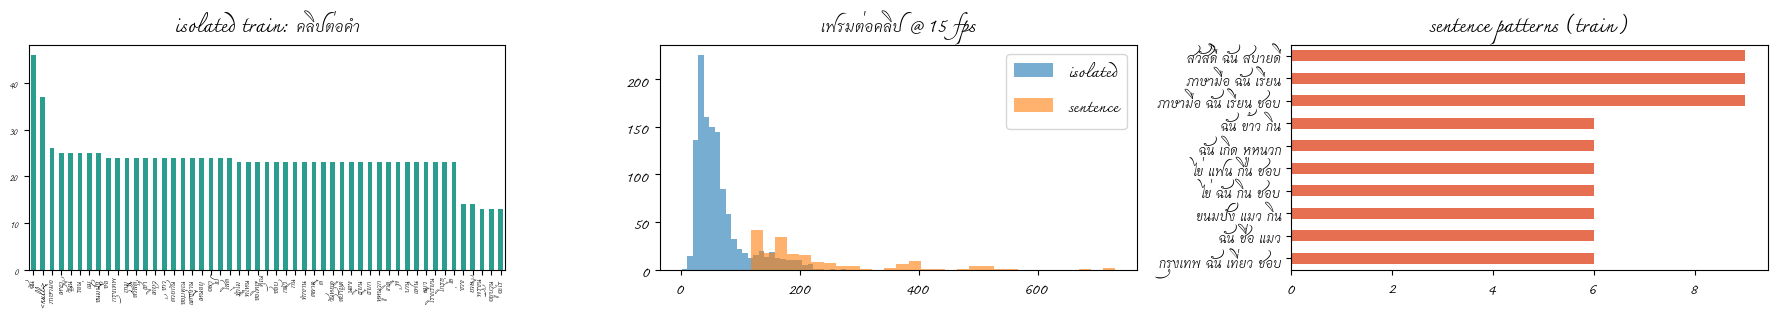

In [2]:
from slm_labs.data import make_splits, split_report, make_loader, make_synthetic_sentences, trim_items, holdout_classes
from slm_labs.vocab import SIGN_CLASSES, CLASS2WORD, N_CLASSES, KNOWN_WORDS, UNK, NULL_CLASS

iso_user, iso_expert, sent_all = pickle.load(open(cfg.OUT_DIR / f"items_raw_{cfg.TARGET_FPS:g}fps.pkl", "rb"))
iso_user, iso_expert = trim_items(iso_user), trim_items(iso_expert)
iso, sent = make_splits(iso_user, iso_expert, sent_all)
print(f"isolated {len(iso['train'])}/{len(iso['val'])}/{len(iso['test'])} | sentence {len(sent['train'])}/{len(sent['val'])}/{len(sent['test'])}")
display(split_report(iso, sent))          # ทุกค่าต้องเป็น 0

fig, ax = plt.subplots(1, 3, figsize=(18, 3.4))
pd.Series([CLASS2WORD[SIGN_CLASSES[it["label"]]] for it in iso["train"]]).value_counts().plot.bar(ax=ax[0], color="#2a9d8f")
ax[0].set_title("isolated train: คลิปต่อคำ"); ax[0].tick_params(labelsize=8)
ax[1].hist([len(it["feat"]["hand"]) for it in iso["train"]], 30, alpha=.6, label="isolated")
ax[1].hist([len(it["feat"]["hand"]) for it in sent["train"]], 30, alpha=.6, label="sentence")
ax[1].legend(); ax[1].set_title(f"เฟรมต่อคลิป @ {cfg.TARGET_FPS:g} fps")
pd.Series([it["pattern"] for it in sent["train"]]).value_counts().head(10).plot.barh(ax=ax[2], color="#e76f51")
ax[2].invert_yaxis(); ax[2].set_title("sentence patterns (train)")
plt.tight_layout(); plt.show()

## 2. บั๊กที่ทำให้ v1/v2 อ่านวิดีโอจริงไม่ออก — frame rate

`user_sign_metadata.fps_extracted = 30` (t_ms dt ≈ 42 ms → ~24 fps จริง) แต่ `cfg.TARGET_FPS` เดิม = 10
→ `HolisticExtractor` ดึงวิดีโอใหม่ที่ 10 fps ท่าเดียวกันจึงสั้นกว่าที่ Stage A เคยเห็น 2.5 เท่า

เซลล์นี้เทียบ "กี่วินาทีต่อหนึ่งท่า" ของ dataset กับวิดีโอทดสอบ ทั้งก่อนและหลังแก้

In [3]:
import pandas as pd
raw = pd.read_csv(cfg.DATA_DIR / "metadata/user_sign_metadata.csv")
rows = [dict(source="dataset user_sign", fps_meta=raw["fps_extracted"].median(), frames_meta=raw["frames_extracted"].median(),
             sec=raw["frames_extracted"].median() / raw["fps_extracted"].median()),
        dict(source=f"หลัง resample @ {cfg.TARGET_FPS:g} fps", fps_meta=cfg.TARGET_FPS,
             frames_meta=np.median([len(i["feat"]["hand"]) for i in iso_user]),
             sec=np.median([len(i["feat"]["hand"]) for i in iso_user]) / cfg.TARGET_FPS)]
for p in sorted((cfg.OUT_DIR / "landmarks_cache").glob(f"*@{cfg.TARGET_FPS:g}fps.csv")):
    d = pd.read_csv(p); rows.append(dict(source="วิดีโอจริง " + p.stem.split("@")[0][:16], fps_meta=cfg.TARGET_FPS,
                                         frames_meta=len(d), sec=len(d) / cfg.TARGET_FPS))
display(pd.DataFrame(rows).round(2))
print("→ dataset กับวิดีโอใหม่ต้องอยู่บนแกนเวลาเดียวกัน ไม่งั้น Transformer เห็นคนละความเร็วของท่าเดียวกัน")

,source,fps_meta,frames_meta,sec
0,dataset user_sign,30.0,90.0,3.00
1,หลัง resample @ 15 fps,15.0,49.0,3.27
2,วิดีโอจริง ฉันปลอบเพื่อนร้อ,15.0,154.0,10.27
3,วิดีโอจริง ไปทานข้าวด้วยกัน,15.0,101.0,6.73


→ dataset กับวิดีโอใหม่ต้องอยู่บนแกนเวลาเดียวกัน ไม่งั้น Transformer เห็นคนละความเร็วของท่าเดียวกัน


## 3. Stage A — SignEncoder + ArcFace

```
Hand ─► MLP ─┐                                                ┌─► masked-mean ─► cls head  ─ CE
Body ─► MLP ─┼─► fusion ─► +pos ─► Transformer (pre-LN, 4L) ─┼─► masked-mean ─► emb head ─ ArcFace(s=24, m=0.25)
Face ─► MLP ─┘                                                └─► per-frame(÷4) ─► ctc head (Stage B)
```
ArcFace คือส่วนที่ทำให้ `cos(emb, prototype)` มีความหมาย — ของเดิม emb head ไม่มี loss ใดแตะเลย
(ตรวจได้: `max|Δweight|` ระหว่าง checkpoint ที่ train แล้วกับ random init = 0 พอดี)

params: 3.01 M


isolated TEST  acc=0.9439  macro-F1=0.9510


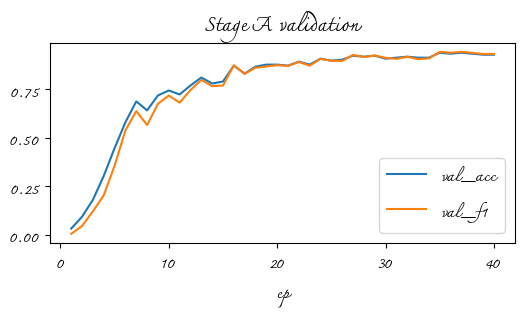

In [4]:
from slm_labs.model import build_model
from slm_labs.train import train_stage_a, train_stage_b, load_checkpoint, save_checkpoint
from slm_labs.metrics import eval_isolated, eval_sequence, eval_isolated_shifted, openset_auroc, tune_blank_penalty

dl_iso_tr = make_loader(iso["train"], cfg.MAX_FRAMES_ISO, True,  False)
dl_iso_va = make_loader(iso["val"],   cfg.MAX_FRAMES_ISO, False, False)
dl_iso_te = make_loader(iso["test"],  cfg.MAX_FRAMES_ISO, False, False)

seed_all(cfg.SEED); model = build_model(N_CLASSES, DEVICE)
print(f"params: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")
if RETRAIN:
    histA = train_stage_a(model, dl_iso_tr, dl_iso_va, cfg.EPOCHS_A, tag="v3_stageA")
else:
    load_checkpoint(model, cfg.OUT_DIR / "v3_stageA_best.pt"); histA = pd.read_csv(cfg.OUT_DIR / "hist_v3_stageA.csv")
resA = eval_isolated(model, dl_iso_te)
print(f"isolated TEST  acc={resA['acc']:.4f}  macro-F1={resA['macro_f1']:.4f}")
histA.plot(x="ep", y=["val_acc", "val_f1"], figsize=(6, 2.6), title="Stage A validation"); plt.show()

## 4. Embedding / prototypes / open-set

- prototype ต่อ class = mean ของ emb บน train · `τ_sim` = quantile ที่ 10 ของ cosine(class ถูก) บน val
- วัด open-set 2 แบบ
  1. **pseudo-unknown** — คลิปเดิมเล่นย้อนกลับ (โปรโตคอลเดิมของ v1/v2)
  2. **held-out classes** — กัน 8 คำออกจาก train ทั้งหมด แล้วถามว่าโมเดลรู้ตัวไหมว่า "ไม่รู้จักคำนี้" ← อันนี้คือของจริง

tau_sim=0.600 {'val_correct_sim_mean': 0.822, 'val_correct_sim_std': 0.151, 'val_nn_acc': 0.933, 'val_max_sim_mean': 0.836, 'val_wrong_sim_mean': 0.362, 'val_cls_conf_mean': 0.802, 'n_train': 1189, 'n_val': 195}


,model,protocol,auroc,tnr_at_95tpr,thr,known_mean,unknown_mean
0,v3 (ArcFace),pseudo-unknown (time-reversed),0.6080,0.0867,0.6330,0.8418,0.8055
1,no-arc (v1/v2 style),pseudo-unknown (time-reversed),0.6100,0.0663,0.6443,0.8504,0.8220
2,v3 (ArcFace),held-out 8 classes,0.8626,0.3036,0.5776,0.8385,0.6591
3,no-arc (v1/v2 style),held-out 8 classes,0.8023,0.3036,0.6873,0.8583,0.7576


held-out: ['คุณ', 'ยาย', 'แมว', 'เรียก', 'ชอบ', 'ไป', 'เช้า', 'กรุงเทพ']


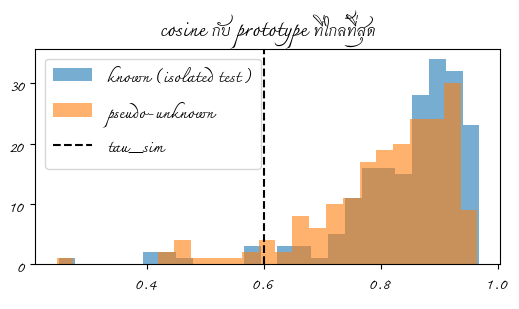

In [5]:
from slm_labs.openset import (Prototypes, analyze_clip, eval_sequence_segments, eval_segment_count,
                              known_unknown_scores, tune_segmentation, tune_openset_thresholds, SEG_PARAMS)
from slm_labs.features import time_reverse

protos = Prototypes.load(cfg.OUT_DIR / "prototypes.npz") if not RETRAIN else Prototypes.build(model, iso["train"], iso["val"])
print("tau_sim=%.3f" % protos.sim_thr, {k: round(v, 3) for k, v in protos.stats.items()})

summary = json.loads((cfg.OUT_DIR / "summary_v3.json").read_text(encoding="utf-8"))
display(pd.DataFrame(summary["openset"]))
print("held-out:", summary["holdout_classes"])

ks, us = known_unknown_scores(model, protos, iso["test"], [dict(feat=time_reverse(it["feat"])) for it in iso["test"]])
plt.figure(figsize=(6, 2.8)); plt.hist(ks, 25, alpha=.6, label="known (isolated test)")
plt.hist(us, 25, alpha=.6, label="pseudo-unknown"); plt.axvline(protos.sim_thr, color="k", ls="--", label="tau_sim")
plt.legend(); plt.title("cosine กับ prototype ที่ใกล้ที่สุด"); plt.show()

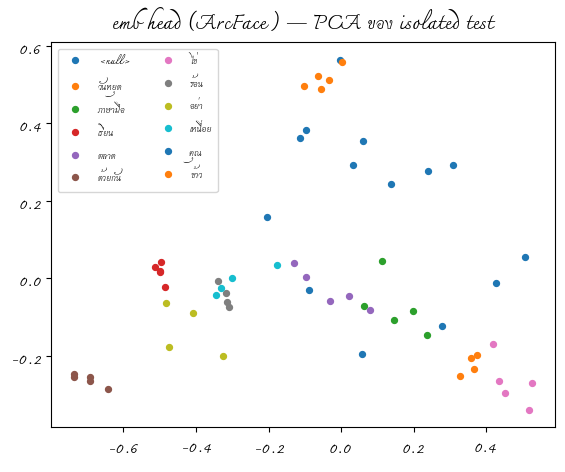

In [6]:
# embedding space (PCA) — 12 คำที่มีคลิปมากที่สุดใน test
from sklearn.decomposition import PCA
E, _ = Prototypes.embed_items(model, iso["test"]); y = np.array([it["label"] for it in iso["test"]])
top = pd.Series(y).value_counts().head(12).index.tolist()
mask = np.isin(y, top); P2 = PCA(2).fit_transform(E)
plt.figure(figsize=(6.5, 5))
for c in top:
    sel = (y == c)
    plt.scatter(P2[sel, 0], P2[sel, 1], s=18, label=CLASS2WORD[SIGN_CLASSES[c]])
plt.legend(fontsize=9, ncol=2); plt.title("emb head (ArcFace) — PCA ของ isolated test"); plt.show()

## 5. Segmentation — "มีกี่คำ" โดยไม่ใช้ vocab

สองสัญญาณรวมกัน
1. **hand-activity** : ความเร็วมือ + ข้อมือยกเหนือระดับพัก → ช่วงที่กำลังทำท่า (grid-search บน sentence-train)
2. **CTC frame-posterior** : ใช้เป็น *ตัวเสนอขอบเขต* เท่านั้น — diagnostic พบว่า CTC เรียง "ตำแหน่ง" ของคำถูก
   แม้ P(blank)≈0.97 จะทำให้ greedy decode ออกมาว่าง คือ alignment ดีแต่ calibration พัง จึงเอาเฉพาะส่วนที่มันเก่งมาใช้
   → ช่วยตัด segment ที่ยาวเกินในคลิปจริง ซึ่งเซ็นเร็วกว่า dataset ~2 เท่า

,min_dist,prominence,energy_frac,min_frames,smooth,mae,bias,exact,within1
0,20,0.45,0.25,10,5,1.383333,-0.027778,0.222222,0.622222
1,20,0.45,0.40,10,5,1.383333,-0.027778,0.222222,0.622222
2,20,0.45,0.55,10,5,1.383333,-0.027778,0.222222,0.622222
3,16,0.45,0.25,10,5,1.388889,0.100000,0.227778,0.622222
4,16,0.45,0.40,10,5,1.388889,0.100000,0.227778,0.622222


SEG_PARAMS = {'min_frames': 10, 'min_dist': 20, 'prominence': 0.45, 'energy_frac': 0.25, 'wrist_y': 1.6, 'smooth': 5}


,method,mae,bias,exact,within1
0,motion-only,1.357,0.119,0.143,0.714
1,motion+CTC cuts,2.095,2.000,0.167,0.452


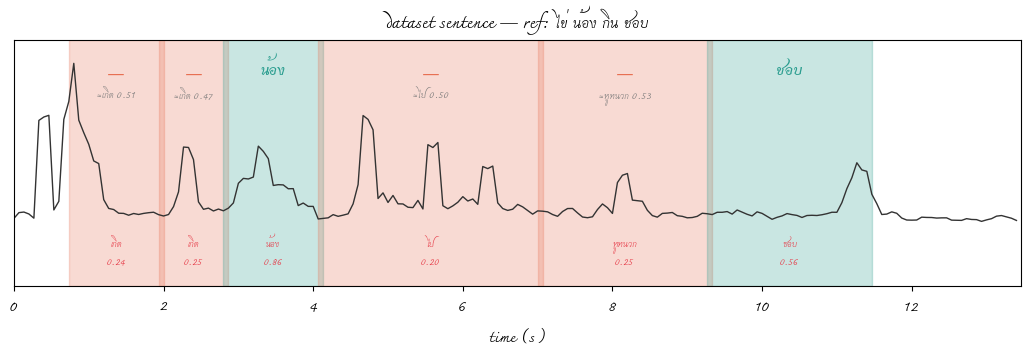

In [7]:
tune = tune_segmentation(sent["train"], set_global=True)
display(tune.head(5)); print("SEG_PARAMS =", SEG_PARAMS)
display(pd.DataFrame(summary["segcount"]))

it = sent["test"][0]
a = analyze_clip(model, it["feat"], protos)
plot_timeline(a, f"dataset sentence — ref: {it['pattern']}"); plt.show()

## 6. Stage B — สองทางเลือก (ทั้งคู่ไม่แตะ encoder)

| | ฝึกอะไร | ใช้ทำอะไร |
|---|---|---|
| **B-ctc** | `ctc_head` 13.6k พารามิเตอร์ บน encoder ที่ freeze | ถอดลำดับ gloss ทั้งประโยค + เป็นตัวเสนอขอบเขตให้ B-seg |
| **B-seg** | ไม่ต้องฝึกเพิ่ม | segment → classify + open-set → ได้ `_` สำหรับคำนอก vocab (ทางหลักของ pipeline) |

เพราะ encoder ถูก freeze ความแม่นของ Stage A จึง **เท่าเดิมเป๊ะ** หลัง Stage B (v2 เคยตกจาก 0.988 → 0.337)

In [8]:
dl_seq_va = make_loader(sent["val"],  cfg.MAX_FRAMES_SEQ, False, True, bs=16)
dl_seq_te = make_loader(sent["test"], cfg.MAX_FRAMES_SEQ, False, True, bs=16)
if RETRAIN:
    syn = make_synthetic_sentences(iso["train"], cfg.SYN_SENTENCES, sent["train"])
    dl_seq_tr = make_loader(sent["train"] + syn, cfg.MAX_FRAMES_SEQ, True, True, bs=16)
    train_stage_b(model, dl_seq_tr, dl_seq_va, cfg.EPOCHS_B, tag="v3_stageB")
    display(tune_blank_penalty(model, dl_seq_va).head())
else:
    load_checkpoint(model, cfg.OUT_DIR / "sign_encoder_v3.pt")
    cfg.BLANK_PENALTY = summary["stage_b"]["ctc"]["blank_penalty"]
    cfg.SEG_CLS_CONF  = summary["stage_b"]["seg"]["seg_cls_conf"]; protos.sim_thr = summary["stage_b"]["seg"]["tau"]

print("BLANK_PENALTY =", cfg.BLANK_PENALTY, "| SEG_CLS_CONF =", cfg.SEG_CLS_CONF, "| tau_sim =", round(protos.sim_thr, 3))
b = summary["stage_b"]
display(pd.DataFrame([
    dict(**{"Stage B": "B-ctc (blank penalty = 0)"}, WER=b["ctc"]["wer_bp0"], CER=None, sent_acc=None),
    dict(**{"Stage B": f"B-ctc (blank penalty = {b['ctc']['blank_penalty']:g})"}, WER=b["ctc"]["wer"], CER=b["ctc"]["cer"], sent_acc=b["ctc"]["sent_acc"]),
    dict(**{"Stage B": "B-seg (motion segments เท่านั้น)"}, WER=b["seg"]["wer_no_ctc_cuts"], CER=None, sent_acc=None),
    dict(**{"Stage B": "B-seg (+ CTC boundary cuts)"}, WER=b["seg"]["wer"], CER=b["seg"]["cer"], sent_acc=b["seg"]["sent_acc"]),
]).round(4))
print(f"isolated TEST ก่อน Stage B = {b['iso_acc_before']:.4f} / หลัง = {b['iso_acc_after']:.4f}  → encoder ถูก freeze จริง")

BLANK_PENALTY = 0.0 | SEG_CLS_CONF = 0.4 | tau_sim = 0.6


,Stage B,WER,CER,sent_acc
0,B-ctc (blank penalty = 0),0.7556,NaN,NaN
1,B-ctc (blank penalty = 0),0.7556,0.7752,0.0
2,B-seg (motion segments เท่านั้น),0.7778,NaN,NaN
3,B-seg (+ CTC boundary cuts),0.6889,0.7486,0.0


isolated TEST ก่อน Stage B = 0.9439 / หลัง = 0.9439  → encoder ถูก freeze จริง


In [9]:
r = eval_sequence_segments(model, protos, sent["test"], keep_unknown=True)
display(pd.DataFrame({"ref (gloss จริง)": [" ".join(x) for x in r["refs"][:8]],
                      "hyp (B-seg, คง '_')": [" ".join(x) for x in r["hyps"][:8]]}))

,ref (gloss จริง),"hyp (B-seg, คง '_')"
0,ไข่ น้อง กิน ชอบ,_ น้อง น้อง กิน ชอบ ฉัน
1,ไข่ น้อง กิน ชอบ,_ น้อง น้อง _ กิน ชอบ ฉัน
2,ไข่ น้อง กิน ชอบ,_ น้อง _ กิน ชอบ
3,คุณ เกิด ที่ไหน,_ _ ร้อน _ _
4,คุณ เกิด ที่ไหน,ฉัน ร้อน ถาม _
5,คุณ เกิด ที่ไหน,ดี _ _ _
6,คุณ ฉัน แฟน,ฉัน ฉัน ฉัน _
7,คุณ ฉัน แฟน,ดี ฉัน ฉัน แฟน _


## 7. วิดีโอจริง `data_test/*.mp4` → คำ → memory → LLM → **เสียง**

- ชื่อไฟล์คือประโยคที่ผู้ใช้ annotate ไว้ ใช้เป็น metadata เท่านั้น (ไม่ใช่ ground truth ของ segment)
- `EXPECTED` = gloss ที่ควรได้ (`_` = คำนอก vocab 51 คำ) ใช้คิด known-recall

memory backend: qdrant | segments: 9


MediaPipe backend: Tasks HolisticLandmarker


quality: frames=154 pose=1.00 face=1.00 LH=0.74 RH=0.88 shoulderW=0.21
  ✓ input OK



=== ฉันปลอบเพื่อนร้องไห้ ===
  SIGNS : _ หูหนวก _ ภาษามือ
    [0]  1.67- 4.27s  _        unknown  src=none   conf=0.25 sim=0.39  nearest=[('ทำงาน', 0.393), ('วันหยุด', 0.38)]
    [1]  4.27- 4.93s  หูหนวก   known    src=cls+proto conf=0.54 sim=0.74  nearest=[('หูหนวก', 0.737), ('เที่ยว', 0.364)]
    [2]  4.93- 6.13s  _        unknown  src=none   conf=0.11 sim=0.48  nearest=[('ชื่อ', 0.476), ('ขนมปัง', 0.464)]
    [3]  6.13- 8.53s  ภาษามือ  known    src=cls+proto conf=0.61 sim=0.66  nearest=[('ภาษามือ', 0.659), ('ไข่', 0.257)]
  FACE  : eyebrows raised (question-like / emphasis)
  THAI  : ___ เป็นคนหูหนวก ___ ภาษามือไหม? (gpt-5.6)
  LLM guesses for '_': {'0': 'คุณ', '2': 'ชื่อ'}
  file-name annotation: ฉันปลอบเพื่อนร้องไห้ | known in name: ['ฉัน'] | hints: {}
  memory: stored 4 segments | latency: {'1_mediapipe_s': 0.01, '2_extract_s': 0.03, '3_llm_s': 7.66, '4_tts_s': 7.77, 'total_s': 15.47}
  WER=0.750 known-recall=0.00


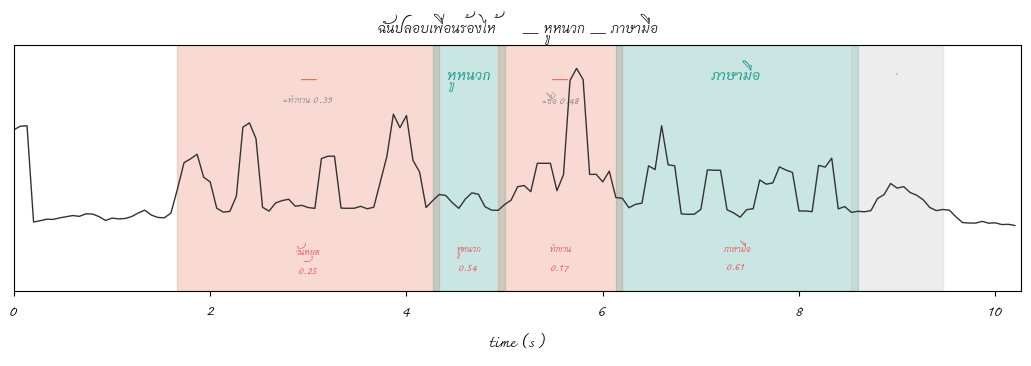

TTS: เป็นคนหูหนวก ภาษามือไหม?


quality: frames=101 pose=1.00 face=1.00 LH=1.00 RH=0.98 shoulderW=0.21
  ✓ input OK



=== ไปทานข้าวด้วยกันมั้ย ===
  SIGNS : ทำงาน ทำงาน _ _ _
    [0]  0.00- 1.74s  ทำงาน    known    src=cls+proto conf=0.85 sim=0.89  nearest=[('ทำงาน', 0.892), ('คุณ', 0.365)]
    [1]  1.74- 2.40s  ทำงาน    known    src=cls+proto conf=0.67 sim=0.68  nearest=[('ทำงาน', 0.683), ('ฉัน', 0.341)]
    [2]  2.40- 5.08s  _        unknown  src=none   conf=0.31 sim=0.65  nearest=[('ทำงาน', 0.645), ('วันหยุด', 0.471)]
    [3]  5.08- 5.74s  _        unknown  src=none   conf=0.14 sim=0.40  nearest=[('แม่', 0.405), ('ทำงาน', 0.396)]
    [4]  5.74- 6.68s  _        unknown  src=none   conf=0.07 sim=0.45  nearest=[('วันหยุด', 0.447), ('ที่ไหน', 0.426)]
  FACE  : eyebrows raised (question-like / emphasis)
  THAI  : ทำงาน ๆ ___ ___ ___ ใช่ไหม? (gpt-5.6)
  LLM guesses for '_': {'2': 'ทำงาน', '3': 'แม่', '4': 'วันหยุด'}
  file-name annotation: ไปทานข้าวด้วยกันมั้ย | known in name: ['ไป', 'ด้วยกัน', 'ข้าว'] | hints: {}
  memory: stored 5 segments | latency: {'1_mediapipe_s': 0.01, '2_extract_s': 0.03, '3_llm

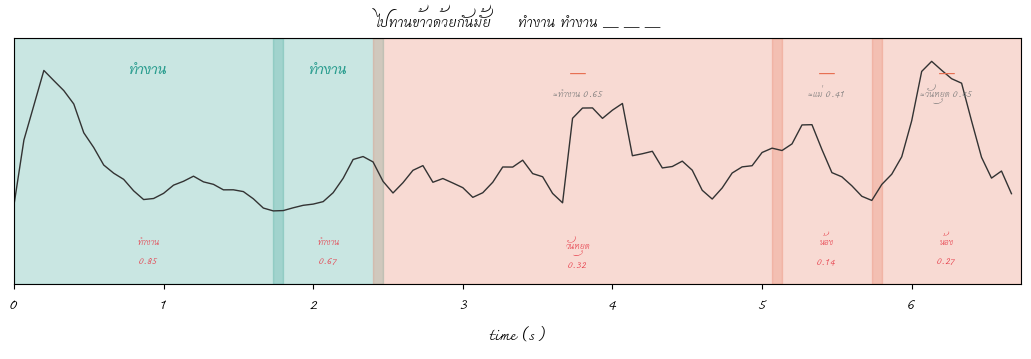

TTS: ทำงาน ๆ ใช่ไหม?


In [10]:
from slm_labs.extractor import HolisticExtractor
from slm_labs.memory import SignMemory
from slm_labs.pipeline import SLMPipeline
from slm_labs.llm import set_face_baseline
from slm_labs.tts import tts, speakable

set_face_baseline(iso["train"], cfg.OUT_DIR / "face_baseline.npz")
EXPECTED = {"ไปทานข้าวด้วยกันมั้ย": ["ไป", "_", "ข้าว", "ด้วยกัน", "_"],
            "ฉันปลอบเพื่อนร้องไห้": ["ฉัน", "_", "_", "_"]}
memory = SignMemory(root=cfg.MEMORY_DIR / "v3")
print("memory backend:", memory.backend, "| segments:", memory.count())
pipe = SLMPipeline(model=model, protos=protos, memory=memory, extractor=HolisticExtractor())

results = {}
for v in sorted(cfg.DATA_TEST_DIR.glob("*.mp4")):
    display(Video(str(v), width=300))
    results[v.stem] = pipe.run(v, expected_words=EXPECTED.get(v.stem), speak=True)
    plot_timeline(results[v.stem]["_analysis"], f"{v.stem}  →  {' '.join(results[v.stem]['words'])}"); plt.show()
    if results[v.stem]["wav"]:
        print("TTS:", speakable(results[v.stem]["thai"])); display(Audio(results[v.stem]["wav"]))

In [11]:
vdf = pd.DataFrame([dict(clip=k, words=" ".join(r["words"]), expected=" ".join(EXPECTED.get(k, [])),
                         known=r["n_known"], unknown=r["n_unknown"], known_recall=r.get("known_recall"),
                         thai=r["thai"], llm=r["llm"], stored=r["memory_stored"]) for k, r in results.items()])
display(vdf); vdf.to_csv(cfg.OUT_DIR / "data_test_results_v3.csv", index=False, encoding="utf-8-sig")
display(memory.table())

,clip,words,expected,known,unknown,known_recall,thai,llm,stored
0,ฉันปลอบเพื่อนร้องไห้,_ หูหนวก _ ภาษามือ,ฉัน _ _ _,2,2,0.0,___ เป็นคนหูหนวก ___ ภาษามือไหม?,gpt-5.6,4
1,ไปทานข้าวด้วยกันมั้ย,ทำงาน ทำงาน _ _ _,ไป _ ข้าว ด้วยกัน _,2,3,0.0,ทำงาน ๆ ___ ___ ___ ใช่ไหม?,gpt-5.6,5


,clip,slot_idx,start_frame,end_frame,t_start_ms,t_end_ms,word,status,source,conf,sim,label,candidate_sentence,known_hits_in_name,created_at
3,ฉันปลอบเพื่อนร้องไห้,0,25,65,1666.666626,4266.666504,_,unknown,none,0.2489,0.3931,None,ฉันปลอบเพื่อนร้องไห้,[ฉัน],2026-09-05T04:37:07
4,ฉันปลอบเพื่อนร้องไห้,1,64,75,4266.666504,4933.333496,หูหนวก,known,cls+proto,0.5433,0.7372,หูหนวก,ฉันปลอบเพื่อนร้องไห้,[ฉัน],2026-09-05T04:37:07
2,ฉันปลอบเพื่อนร้องไห้,2,74,93,4933.333496,6133.333496,_,unknown,none,0.1147,0.4758,None,ฉันปลอบเพื่อนร้องไห้,[ฉัน],2026-09-05T04:37:07
5,ฉันปลอบเพื่อนร้องไห้,3,92,129,6133.333496,8533.333008,ภาษามือ,known,cls+proto,0.6087,0.6588,ภาษามือ,ฉันปลอบเพื่อนร้องไห้,[ฉัน],2026-09-05T04:37:07
7,ไปทานข้าวด้วยกันมั้ย,0,0,27,0.000000,1736.800049,ทำงาน,known,cls+proto,0.8497,0.8917,ทำงาน,ไปทานข้าวด้วยกันมั้ย,"[ไป, ด้วยกัน, ข้าว]",2026-09-05T04:37:17
8,ไปทานข้าวด้วยกันมั้ย,1,26,37,1736.800049,2404.800049,ทำงาน,known,cls+proto,0.6744,0.6835,ทำงาน,ไปทานข้าวด้วยกันมั้ย,"[ไป, ด้วยกัน, ข้าว]",2026-09-05T04:37:17
1,ไปทานข้าวด้วยกันมั้ย,2,36,77,2404.800049,5076.799805,_,unknown,none,0.3134,0.6451,None,ไปทานข้าวด้วยกันมั้ย,"[ไป, ด้วยกัน, ข้าว]",2026-09-05T04:37:17
0,ไปทานข้าวด้วยกันมั้ย,3,76,87,5076.799805,5744.799805,_,unknown,none,0.1384,0.4048,None,ไปทานข้าวด้วยกันมั้ย,"[ไป, ด้วยกัน, ข้าว]",2026-09-05T04:37:17
6,ไปทานข้าวด้วยกันมั้ย,4,86,101,5744.799805,6680.000000,_,unknown,none,0.0741,0.4471,None,ไปทานข้าวด้วยกันมั้ย,"[ไป, ด้วยกัน, ข้าว]",2026-09-05T04:37:17


## 8. เรียนคำใหม่โดยไม่ retrain (annotate → learned prototype)

ดู `memory.table()` / timeline / overlay → บอกว่า slot ไหนคือคำอะไร → `memory.annotate()` →
segment นั้นกลายเป็น learned prototype → รอบหน้า `analyze_clip` คืนคำนั้นทันที (status `learned`)

In [12]:
import shutil
demo = cfg.MEMORY_DIR / "_demo_v3"; shutil.rmtree(demo, ignore_errors=True)
mem_demo = SignMemory(root=demo)
pipe_demo = SLMPipeline(model=model, protos=protos, memory=mem_demo, extractor=pipe.extractor)
clip = "ไปทานข้าวด้วยกันมั้ย"
r0 = pipe_demo.run(cfg.DATA_TEST_DIR / f"{clip}.mp4", translate=False, speak=False, show=False)
slots0 = [s for s in r0["slots"] if s["status"] != "null"]
print("ก่อน annotate:", [f"{s['idx']}:{s['word']}({s['status']})" for s in slots0])

unk_tokens = [t for t in r0["filename_annotation"]["tokens"] if t not in KNOWN_WORDS] or ["?"]
labels, j = {}, 0
for s in slots0:
    if s["status"] in ("known", "learned"):
        labels[s["idx"]] = s["word"]
    else:
        labels[s["idx"]] = unk_tokens[min(j, len(unk_tokens) - 1)]; j += 1
print("annotate:", labels, "→", mem_demo.annotate(clip, labels, note="demo: map จากชื่อไฟล์"), "segments")
print("learned prototypes:", {k: v["n"] for k, v in mem_demo.learned_prototypes().items()})

r1 = pipe_demo.run(cfg.DATA_TEST_DIR / f"{clip}.mp4", translate=True, speak=True, show=False, save_memory=False)
print("หลัง annotate :", r1["words"], "→ THAI:", r1["thai"], f"({r1['llm']})")
print("   status:", [(s["idx"], s["word"], s["status"], round(s["sim"], 3)) for s in r1["slots"] if s["status"] != "null"])
if r1["wav"]: display(Audio(r1["wav"]))

ก่อน annotate:

 ['0:ทำงาน(known)', '1:ทำงาน(known)', '2:_(unknown)', '3:_(unknown)', '4:_(unknown)']
annotate: {0: 'ทำงาน', 1: 'ทำงาน', 2: 'ทานข้าว', 3: 'มั้ย', 4: 'มั้ย'} → 5 segments
learned prototypes: {'มั้ย': 2, 'ทานข้าว': 1, 'ทำงาน': 2}


หลัง annotate : ['ทำงาน', 'ทำงาน', 'ทานข้าว', 'มั้ย', 'มั้ย'] → THAI: ทำงานแล้วทานข้าวไหม? (gpt-5.6)
   status: [(0, 'ทำงาน', 'known', 0.892), (1, 'ทำงาน', 'known', 0.683), (2, 'ทานข้าว', 'learned', 1.0), (3, 'มั้ย', 'learned', 0.896), (4, 'มั้ย', 'learned', 0.896)]


## 9. Overlay video (ตรวจว่า segment ตรงกับท่าจริงไหม)

In [13]:
k0 = sorted(results)[0]
ov = render_overlay_video(cfg.DATA_TEST_DIR / f"{k0}.mp4", results[k0]["_analysis"],
                          cfg.OUT_DIR / "inference" / f"{k0}_overlay_v3.mp4")
print("overlay →", ov); display(Video(str(ov), width=320))

overlay → D:\SLM-labs\SLM-Labs\outputs\inference\ฉันปลอบเพื่อนร้องไห้_overlay_v3.mp4


## 10. สรุป — v1 / v2 (เดิม) เทียบ v3

> **อ่านตัวเลขให้ถูก**: คอลัมน์ v1/v2 มาจาก split เดิมที่ pattern ของประโยครั่ว 100% และ isolated แบ่งแบบสุ่ม
> (signer เดียวกันอยู่ทั้ง train และ test) ส่วน v3 ใช้ split ที่ไม่รั่ว ตัวเลข isolated ที่ต่ำลงคือ *ตัวเลขที่จริง*
> ไม่ใช่ regression — เซลล์สุดท้ายรัน v3 บน split เดิมเพื่อเทียบแบบ apples-to-apples ด้วย

In [14]:
S = summary
rows = [
 ("Sign recognition (isolated test)", "accuracy",           0.9759, 0.3373, S["stage_a"]["acc"]),
 ("Sign recognition (isolated test)", "macro-F1",           0.9806, 0.2518, S["stage_a"]["macro_f1"]),
 ("Sign recognition หลัง Stage B",    "accuracy",           0.9759, 0.3373, S["stage_b"]["iso_acc_after"]),
 ("Sentence (WER)",                   "Stage B ดีที่สุด",   1.0,    1.0,    min(S["stage_b"]["seg"]["wer"], S["stage_b"]["ctc"]["wer"])),
 ("Sentence (CER)",                   "Stage B ดีที่สุด",   1.0,    1.0,    min(S["stage_b"]["seg"]["cer"], S["stage_b"]["ctc"]["cer"])),
 ("Open-set (pseudo-unknown)",        "AUROC",              0.5622, 0.5007, [r for r in S["openset"] if r["protocol"].startswith("pseudo") and r["model"].startswith("v3")][0]["auroc"]),
 ("Open-set (held-out 8 คำ)",         "AUROC",              None,   None,   [r for r in S["openset"] if r["protocol"].startswith("held") and r["model"].startswith("v3")][0]["auroc"]),
 ("Segment count (sentence test)",    "MAE",                2.581,  2.419,  S["segcount"][-1]["mae"]),
]
summary_df = pd.DataFrame(rows, columns=["stage", "metric", "v1 (leaky split)", "v2 (leaky split)", "v3"])
display(summary_df.round(4)); summary_df.to_csv(cfg.OUT_DIR / "metrics_summary_v3.csv", index=False, encoding="utf-8-sig")
display(pd.DataFrame(S["shift"]))
display(pd.DataFrame([dict(clip=v["clip"], v1_v2="_ _ _ _ / (ไม่มีอะไร)", v3=v["words"], expected=v["expected"],
                           known_recall=v["known_recall"]) for v in S.get("videos", [])]))

,stage,metric,v1 (leaky split),v2 (leaky split),v3
0,Sign recognition (isolated test),accuracy,0.9759,0.3373,0.9439
1,Sign recognition (isolated test),macro-F1,0.9806,0.2518,0.9510
2,Sign recognition หลัง Stage B,accuracy,0.9759,0.3373,0.9439
3,Sentence (WER),Stage B ดีที่สุด,1.0000,1.0000,0.6889
4,Sentence (CER),Stage B ดีที่สุด,1.0000,1.0000,0.7486
5,Open-set (pseudo-unknown),AUROC,0.5622,0.5007,0.6080
6,Open-set (held-out 8 คำ),AUROC,NaN,NaN,0.8626
7,Segment count (sentence test),MAE,2.5810,2.4190,2.0950


,strength,acc,macro_f1
0,0.0,0.9439,0.9510
1,1.0,0.9286,0.9362
2,1.6,0.9235,0.9310
3,2.2,0.9031,0.9090


,clip,v1_v2,v3,expected,known_recall
0,ฉันปลอบเพื่อนร้องไห้,_ _ _ _ / (ไม่มีอะไร),_ หูหนวก _ ภาษามือ,ฉัน _ _ _,0.0
1,ไปทานข้าวด้วยกันมั้ย,_ _ _ _ / (ไม่มีอะไร),ทำงาน ทำงาน _ _ _,ไป _ ข้าว ด้วยกัน _,0.0


In [15]:
# apples-to-apples: v3 บน split เดิมของ v1/v2 (pattern รั่ว + isolated สุ่ม)
from slm_labs.data import make_splits as mk
iso_old, sent_old = mk(iso_user, iso_expert, sent_all, mode="random", sent_by_pattern=False)
print("pattern overlap train/test ของ split เดิม =",
      len({i["pattern"] for i in sent_old["train"]} & {i["pattern"] for i in sent_old["test"]}), "(ควรเป็น 0 ถ้าไม่รั่ว)")
if RETRAIN:
    seed_all(cfg.SEED); m_old = build_model(N_CLASSES, DEVICE)
    train_stage_a(m_old, make_loader(iso_old["train"], cfg.MAX_FRAMES_ISO, True, False),
                  make_loader(iso_old["val"], cfg.MAX_FRAMES_ISO, False, False), cfg.EPOCHS_A, tag="v3_oldsplit")
else:
    m_old = build_model(N_CLASSES, DEVICE); load_checkpoint(m_old, cfg.OUT_DIR / "v3_oldsplit_best.pt")
r_old = eval_isolated(m_old, make_loader(iso_old["test"], cfg.MAX_FRAMES_ISO, False, False))
print(f"v3 บน split เดิม: isolated TEST acc={r_old['acc']:.4f} F1={r_old['macro_f1']:.4f}   "
      f"(v1=0.9759 / v2=0.3373 / v3 บน split ที่ไม่รั่ว={S['stage_a']['acc']:.4f})")

pattern overlap train/test ของ split เดิม = 62 (ควรเป็น 0 ถ้าไม่รั่ว)


v3 บน split เดิม: isolated TEST acc=0.9880 F1=0.9908   (v1=0.9759 / v2=0.3373 / v3 บน split ที่ไม่รั่ว=0.9439)


### สิ่งที่ยังทำต่อได้
- **segmentation** ยังเป็นจุดคอขวดของการอ่านทั้งประโยค — ทางที่ตรงที่สุดคือเก็บ boundary annotation ของ
  sentence clip สัก 50-100 คลิป แล้ว train boundary detector แทน heuristic
- **ข้อมูล** — 51 คำ / signer 3 คน / 76 pattern เล็กเกินไปสำหรับ continuous recognition; expert augmented 32k คลิป
  ใช้เป็น unlabeled pool ได้ถ้าจะกลับไปทำ SSL อีกครั้ง (คราวนี้วัดผลบน split ที่ไม่รั่ว)
- **memory** — เมื่อ annotate สะสมพอ ให้เอา segment เหล่านั้นมาเป็น isolated sample แล้ว fine-tune Stage A เพิ่ม class จริง
- **open-set** — ตอนนี้ใช้ threshold เดียวทั้งระบบ; per-class threshold หรือ energy-based OOD น่าจะดีกว่า